# 4. Clustering

Customer segmentation using:
- KMeans.
- Dendrograms / Hierarchical clustering.
- PCA for visualization.

Dataset shape: (10000, 15)
      category   price  quantity delivery_status payment_method device_type  \
0        Books   45.95         4         Shipped         PayPal      Mobile   
1  Electronics  403.17         3       Delivered         PayPal      Mobile   
2       Beauty  317.45         2         Shipped    Credit Card      Mobile   
3         Home   24.08         3         Shipped         PayPal      Tablet   
4     Clothing  494.90         1       Delivered         PayPal      Tablet   

       channel customer_segment  order_month  order_day  order_hour  \
0  Paid Search              VIP            4         20          14   
1  Paid Search        Returning            4         20          14   
2        Email        Returning            4         20          14   
3       Social              VIP            4         20          14   
4      Organic              VIP            4         20          14   

   shipping_month  shipping_day  shipping_hour  shipping_delay  
0     

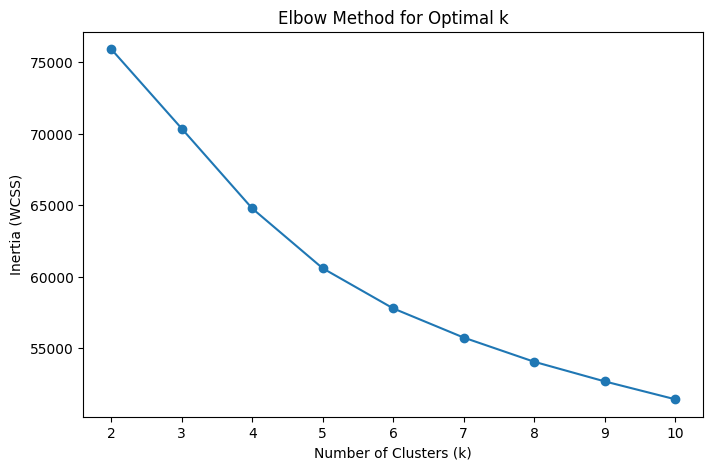

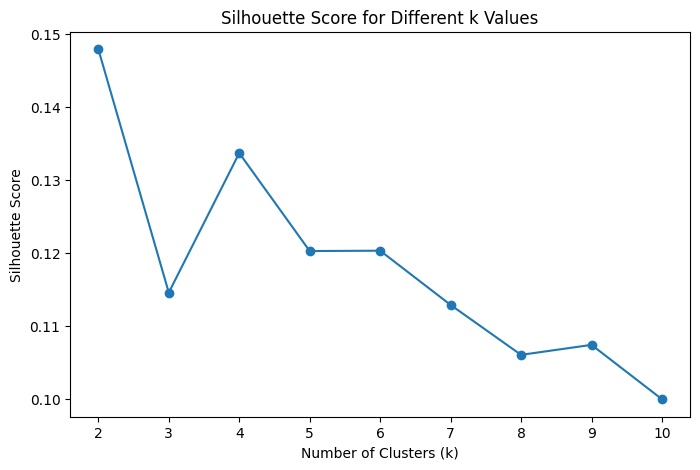

k=2, Silhouette Score=0.1480
k=3, Silhouette Score=0.1146
k=4, Silhouette Score=0.1337
k=5, Silhouette Score=0.1203
k=6, Silhouette Score=0.1203
k=7, Silhouette Score=0.1129
k=8, Silhouette Score=0.1060
k=9, Silhouette Score=0.1074
k=10, Silhouette Score=0.0999

Selected optimal k: 4

Cluster counts:
cluster
0    2627
1    2546
2    1308
3    3519
Name: count, dtype: int64

===== NUMERICAL CLUSTER SUMMARY =====
              price  quantity  order_month  order_day  order_hour  \
cluster                                                             
0        255.756943  2.125238     4.062809   6.695470        14.0   
1        250.021100  2.124902     4.099372  20.847604        14.0   
2        257.947049  2.142966     6.421254  28.415902        14.0   
3        249.981489  2.117363    10.034669  14.068201        14.0   

         shipping_month  shipping_day  shipping_hour  shipping_delay  
cluster                                                               
0              4.062809     

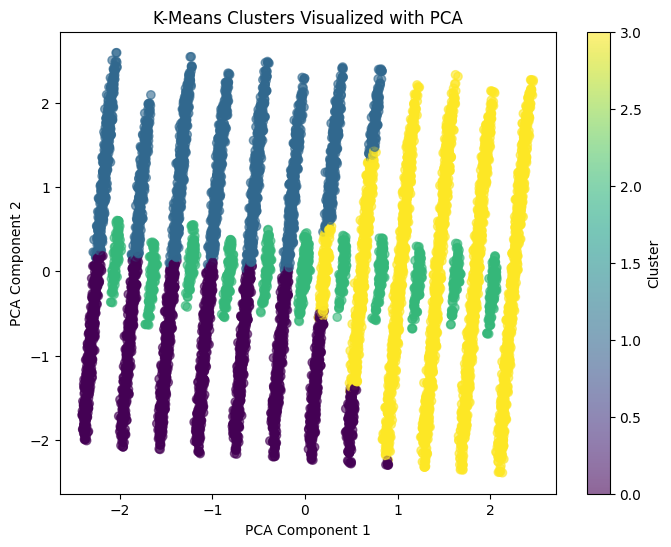


===== CLUSTERING EVALUATION =====
Silhouette Score: 0.13370741428274324

✅ KMeans model saved to ../artifacts/kmeans_model.joblib
✅ Preprocessor saved to ../artifacts/kmeans_preprocessor.joblib
✅ Clustered dataset saved to ../data/clustered_data.csv


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# =====================================================
# 1. LOAD CLEANED DATA
# =====================================================
df = pd.read_csv("../data/cleaned_data.csv")

print("Dataset shape:", df.shape)
print(df.head())

# =====================================================
# 2. FEATURE SELECTION
#    Remove target-like columns for clustering
# =====================================================
clustering_df = df.drop(columns=["price", "customer_segment", "delivery_status"], errors="ignore")

print("\nColumns used for clustering:")
print(clustering_df.columns.tolist())

# =====================================================
# 3. IDENTIFY COLUMN TYPES
# =====================================================
categorical_cols = clustering_df.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_cols = clustering_df.select_dtypes(exclude=["object", "string"]).columns.tolist()

print("\nCategorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

# =====================================================
# 4. PREPROCESSING
#    - Scale numerical columns
#    - Encode categorical columns
# =====================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(clustering_df)

print("\nProcessed feature matrix shape:", X_processed.shape)

# =====================================================
# 5. ELBOW METHOD (k = 2 to 10)
# =====================================================
k_values = range(2, 11)
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal k")
plt.show()

# =====================================================
# 6. SILHOUETTE SCORES FOR k = 2 to 10
# =====================================================
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_processed)
    score = silhouette_score(X_processed, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k Values")
plt.show()

for k, score in zip(k_values, silhouette_scores):
    print(f"k={k}, Silhouette Score={score:.4f}")

# =====================================================
# 7. CHOOSE OPTIMAL k
#    Change this value after inspecting elbow + silhouette
# =====================================================
optimal_k = 4

print(f"\nSelected optimal k: {optimal_k}")

# =====================================================
# 8. FIT FINAL KMEANS MODEL
# =====================================================
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_processed)

# assign clusters
df["cluster"] = cluster_labels

print("\nCluster counts:")
print(df["cluster"].value_counts().sort_index())

# =====================================================
# 9. CLUSTER ANALYSIS
# =====================================================
print("\n===== NUMERICAL CLUSTER SUMMARY =====")
cluster_summary = df.groupby("cluster").mean(numeric_only=True)
print(cluster_summary)

print("\n===== CATEGORICAL MODE PER CLUSTER =====")
for col in ["category", "payment_method", "device_type", "channel"]:
    if col in df.columns:
        print(f"\nMost common {col} by cluster:")
        print(df.groupby("cluster")[col].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

# =====================================================
# 10. BUSINESS-FRIENDLY CLUSTER INTERPRETATION TABLE
# =====================================================
analysis_columns = ["quantity", "shipping_delay"]
existing_analysis_cols = [col for col in analysis_columns if col in df.columns]

business_summary = df.groupby("cluster")[existing_analysis_cols].mean().round(2)
business_summary["cluster_size"] = df["cluster"].value_counts().sort_index().values

print("\n===== BUSINESS SUMMARY =====")
print(business_summary)

# =====================================================
# 11. PCA FOR 2D VISUALIZATION
# =====================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

pca_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "cluster": cluster_labels
})

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_df["PCA1"], pca_df["PCA2"], c=pca_df["cluster"], alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters Visualized with PCA")
plt.colorbar(scatter, label="Cluster")
plt.show()

# =====================================================
# 12. EVALUATE CLUSTERING QUALITY
# =====================================================
sil_score = silhouette_score(X_processed, cluster_labels)

print("\n===== CLUSTERING EVALUATION =====")
print("Silhouette Score:", sil_score)

# =====================================================
# 13. SAVE FINAL MODEL + PREPROCESSOR
# =====================================================
os.makedirs("../artifacts/", exist_ok=True)

joblib.dump(final_kmeans, "../artifacts/kmeans_model.joblib")
joblib.dump(preprocessor, "../artifacts/kmeans_preprocessor.joblib")

print("\n✅ KMeans model saved to ../artifacts/kmeans_model.joblib")
print("✅ Preprocessor saved to ../artifacts/kmeans_preprocessor.joblib")

# =====================================================
# 14. SAVE DATASET WITH CLUSTER LABELS
# =====================================================
df.to_csv("../data/clustered_data.csv", index=False)
print("✅ Clustered dataset saved to ../data/clustered_data.csv")